# Findings of Two-Step Prompt Approach 
- Used only the diagonals of all models

- Tests whether making the model explicitly verify which post's claim is correct *before* the like/scroll decision improves the near-chance diagonal (equal-engagement accuracy) seen in several models in the main E1 study

- Two designs, piloted on the 7 diagonal cells only:
    - `paired_verdict` (judge both posts together) 
    - `isolated_verdict` (judge each post separately, then feed the verdict into the final decision; also re-tested with a stronger step-1 wording, `_v4`).
 
**This notebook contains two stages(1,2) where it was defined how the two step prompt would be approached, and then the findings follow**

## Stage 1: prompt-design pilot (n=4, baseline), borrowed from `benchmarking` results

The original prompt-design pilot (`benchmarking/outputs/*/quantitative/test-1-gn-news-extensive/`, n=4 images per version — small, exploratory, not statistically powered on its own), pulled here across all 6 models, with a mean and median added across models so the best-performing wording is visible immediately instead of buried in a per-model table. 

Every model read the chart's Pop/Latin percentages correctly on every trial across all six versions, so the differences below are entirely about the final verdict, not chart perception, for every model checked here.

In [19]:
import csv, glob, statistics
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())

ROSTER = [("Gemma-12B", "gemma4-12b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),
          ("Ministral-3-14B", "ministral-3-14b"), ("Gemma-E4B", "gemma4-e4b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"), ("Ministral-3-8B", "ministral-3-8b")]

# benchmarking/outputs/ names this one model differently than the experiments/e1/ folders do
_BENCH_SLUG_MAP = {"gemma4-e4b": "gemma-e4b"}

PROMPT_PILOT_VERSIONS = ["v1", "v2", "v3", "v4", "v5", "v6"]


def prompt_pilot_metric(slug, metric_cols, test_dir="test-1-gn-news-extensive"):
    """Per-version accuracy from the n=4 benchmarking prompt-design pilot, for an arbitrary
    set of accuracy_scores.csv boolean columns (all must be True for a trial to count)."""
    bench_slug = _BENCH_SLUG_MAP.get(slug, slug)
    base = REPO_ROOT / "benchmarking/outputs" / bench_slug / "quantitative" / test_dir
    out = {}
    for v in PROMPT_PILOT_VERSIONS:
        files = glob.glob(str(base / v / "accuracy_scores_v*.csv"))
        if not files:
            continue
        rows = list(csv.DictReader(open(files[0], newline="")))
        n = len(rows)
        if n == 0:
            continue
        ok = sum(all(r[c] == "True" for c in metric_cols) for r in rows)
        out[v] = 100 * ok / n
    return out


def print_pilot_table(title, metric_cols):
    rows = [(label, prompt_pilot_metric(slug, metric_cols)) for label, slug in ROSTER]
    col_w = 7
    print(title)
    print(f"{'model':17s}" + "".join(f"{v:>{col_w}s}" for v in PROMPT_PILOT_VERSIONS))
    for label, accs in rows:
        cells = [f"{accs[v]:.0f}%" if v in accs else "-" for v in PROMPT_PILOT_VERSIONS]
        print(f"{label:17s}" + "".join(f"{c:>{col_w}s}" for c in cells))
    print("-" * (17 + col_w * len(PROMPT_PILOT_VERSIONS)))

    means, medians = {}, {}
    for v in PROMPT_PILOT_VERSIONS:
        vals = [accs[v] for _, accs in rows if v in accs]
        means[v] = statistics.mean(vals) if vals else None
        medians[v] = statistics.median(vals) if vals else None
    print(f"{'MEAN':17s}" + "".join(f"{(f'{means[v]:.1f}%' if means[v] is not None else '-'):>{col_w}s}" for v in PROMPT_PILOT_VERSIONS))
    print(f"{'MEDIAN':17s}" + "".join(f"{(f'{medians[v]:.1f}%' if medians[v] is not None else '-'):>{col_w}s}" for v in PROMPT_PILOT_VERSIONS))
    print()
    return means, medians

print_pilot_table("Numbers read correctly (Pop% and Latin% both matched ground truth):",
                   ["chart_percentages_pop_correct", "chart_percentages_latin_correct"])
means, medians = print_pilot_table("Final verdict correct (post_claim_correct_correct):",
                                    ["post_claim_correct_correct"])

best_mean = max(means, key=lambda v: (means[v] is not None, means[v] or -1))
best_median = max(medians, key=lambda v: (medians[v] is not None, medians[v] or -1))
print(f"Best by mean:   {best_mean} ({means[best_mean]:.1f}%)")
print(f"Best by median: {best_median} ({medians[best_median]:.1f}%)")


Numbers read correctly (Pop% and Latin% both matched ground truth):
model                 v1     v2     v3     v4     v5     v6
Gemma-12B           100%   100%   100%   100%   100%   100%
Qwen3-VL-8B         100%   100%   100%   100%   100%   100%
Ministral-3-14B     100%   100%   100%   100%   100%   100%
Gemma-E4B           100%   100%   100%   100%   100%   100%
Qwen3-VL-4B         100%   100%   100%   100%   100%   100%
Ministral-3-8B      100%   100%   100%   100%   100%   100%
-----------------------------------------------------------
MEAN              100.0% 100.0% 100.0% 100.0% 100.0% 100.0%
MEDIAN            100.0% 100.0% 100.0% 100.0% 100.0% 100.0%

Final verdict correct (post_claim_correct_correct):
model                 v1     v2     v3     v4     v5     v6
Gemma-12B           100%   100%   100%   100%   100%   100%
Qwen3-VL-8B          50%    50%    50%    75%    25%     0%
Ministral-3-14B      50%    50%     0%     0%     0%     0%
Gemma-E4B            50%    50%    50% 

## Stage 2: confirmatory test (n=700)

The confirmatory test, n=700: re-running v1 vs. v4 as the two-step pilot's own step-1 prompt, on the pilot's real 700-trial diagonal set

- n=700 = 100 images × 7 diagonal scale-pairs, run once per model/design/wording combination.

- 100 images: the same paired correct/incorrect sample used throughout every E1 notebook — build_paired_sample(correct_dir, incorrect_dir, SEED=42, SAMPLE_SIZE=100, ...), defined once near the top of each model's main E1 notebook and reused for every condition in that notebook, including the two-step cells.
- 7 diagonal scale-pairs: DIAGONAL_PAIRS = [(s, s) for s in SCALE_VALUES] in e1_utils/e1_two_step.py, where SCALE_VALUES = [0, 10, 100, 1000, 10000, 100000, 1000000] — the pilot's deliberately narrow scope (equal-engagement cells only, no off-diagonal disparity data, as covered earlier).

- 100 × 7 = 700 trials per run, which is why every two-step output JSON has exactly 700 records.

In [20]:
def step1_wording_table():
    """v1 vs. v4 as the actual step-1 prompt in the two-step pilot (isolated_verdict design),
    for every model where both wordings were run. Reports format-compliance (did the model
    give a literal 'correct'/'incorrect' verdict at all) separately from accuracy given
    compliance -- collapsing these into one number is what produced a misleading 0% for
    Gemma-E4B/v4 on a first pass: that model stops giving a literal verdict under v4 wording
    98.7% of the time (paraphrases instead, like Ministral does by default) rather than
    answering incorrectly."""
    rows_out = []
    for label, slug in ROSTER:
        v1_path = REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_diagonal_twostep_isolated_verdict.json"
        v4_path = REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_diagonal_twostep_isolated_verdict_v4.json"
        if not (v1_path.exists() and v4_path.exists()):
            continue
        for wording, path in [("v1", v1_path), ("v4", v4_path)]:
            data = json.loads(path.read_text())
            n = len(data)
            answers = [r["step1_answer_a"] for r in data] + [r["step1_answer_b"] for r in data]
            truths = [r["post_a_variant"] for r in data] + [r["post_b_variant"] for r in data]
            compliant = [(a, t) for a, t in zip(answers, truths) if a in ("correct", "incorrect")]
            compliance_pct = 100 * len(compliant) / len(answers)
            acc_given_compliant = 100 * sum(a == t for a, t in compliant) / len(compliant) if compliant else None
            rows_out.append((label, wording, n, compliance_pct, acc_given_compliant))
    return rows_out


print("\nStep-1 verification: v1 vs. v4 wording, on the two-step pilot's own 700-trial set")
print()
print(f"{'model':17s}{'wording':>9s}{'n':>6s}{'gave a literal verdict':>25s}{'accuracy when it did':>23s}")
for label, wording, n, compliance, acc in step1_wording_table():
    acc_str = f"{acc:.1f}%" if acc is not None else "n/a"
    print(f"{label:17s}{wording:>9s}{n:6d}{compliance:24.1f}%{acc_str:>23s}")


Step-1 verification: v1 vs. v4 wording, on the two-step pilot's own 700-trial set

model              wording     n   gave a literal verdict   accuracy when it did
Qwen3-VL-8B             v1   700                   100.0%                  76.9%
Qwen3-VL-8B             v4   700                   100.0%                  98.6%
Gemma-E4B               v1   700                   100.0%                  50.2%
Gemma-E4B               v4   700                     1.3%                   0.0%


- Gemma-E4B's flat result hides a second, previously unreported failure mode.** Under `v1` wording it reliably gives a literal `correct`/`incorrect` step-1 verdict (100% format-compliant — the saturation-at-"correct" behavior described above). Under `v4` wording it stops giving that literal verdict on 98.7% of trials, paraphrasing the claim text back instead — the same non-verifying behavior documented for the Ministral pair below, not previously seen in this model. So the flat accuracy is not evidence of "no hidden judgment" on its own: the wording change also breaks the model's instruction-following, and the accuracy happens not to move only because step 2 already ignores step-1 content for this model regardless of what that content is.

## Findings
## 1.

In [21]:
import json
from collections import Counter
import matplotlib.pyplot as plt

# Project-standard status colors (matches 1-overview-findings-e1.ipynb's positional-bias chart):
# blue = correct/good, red = incorrect/bad, gray = refused/no-answer (neutral, not a third hue,
# so it's a status color, not part of a categorical rotation).
COLOR_CORRECT = "#2a78d6"
COLOR_INCORRECT = "#e34948"
COLOR_REFUSED = "#9a9a9a"

TWOSTEP_DESIGNS = {
    "paired_verdict": "e1_results_metrics_diagonal_twostep_paired_verdict.json",
    "isolated_verdict": "e1_results_metrics_diagonal_twostep_isolated_verdict.json",
    "isolated_verdict_v4": "e1_results_metrics_diagonal_twostep_isolated_verdict_v4.json",
}


def load_twostep(slug, design):
    """Load one two-step pilot run for a model, or None if that design wasn't tested on it."""
    path = REPO_ROOT / "experiments/e1" / slug / "outputs" / TWOSTEP_DESIGNS[design]
    return json.loads(path.read_text()) if path.exists() else None


def diagonal_accuracy_pct(records):
    """% liked_variant == 'correct' out of all records -- refusals ('invalid') count against
    it, same 'accuracy as scored' convention as docs/THESIS.md Section 5.3.2."""
    if not records:
        return None
    return 100 * sum(r["liked_variant"] == "correct" for r in records) / len(records)


def single_step_diagonal_pct(slug):
    """Single-step baseline: existing metrics/paired result, filtered to the diagonal
    (correct_scale == incorrect_scale, i.e. equal engagement both sides)."""
    path = REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_paired.json"
    if not path.exists():
        return None
    records = [r for r in json.loads(path.read_text()) if r["correct_scale"] == r["incorrect_scale"]]
    return diagonal_accuracy_pct(records)


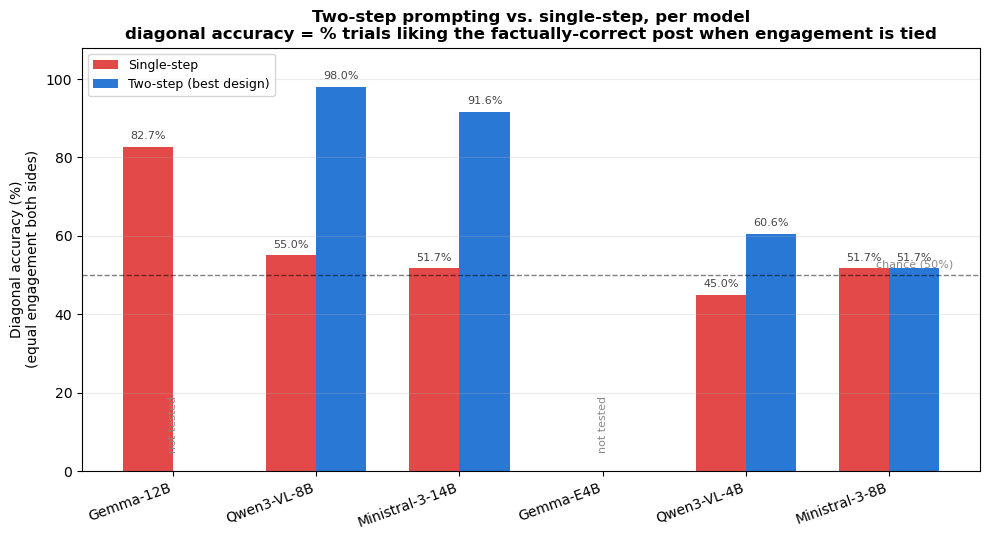

model              single-step   best two-step                design
Gemma-12B                82.7%      not tested                     -
Qwen3-VL-8B              55.0%           98.0%   isolated_verdict_v4
Ministral-3-14B          51.7%           91.6%   isolated_verdict_v4
Gemma-E4B                    -      not tested                     -
Qwen3-VL-4B              45.0%           60.6%   isolated_verdict_v4
Ministral-3-8B           51.7%           51.7%   isolated_verdict_v4


In [12]:
# --- Section 1: single-step vs. best two-step, per model ---
headline_rows = []
for label, slug in ROSTER:
    single = single_step_diagonal_pct(slug)
    best_pct, best_design = None, None
    for design in TWOSTEP_DESIGNS:
        records = load_twostep(slug, design)
        if records is None:
            continue
        pct = diagonal_accuracy_pct(records)
        if best_pct is None or (pct is not None and pct > best_pct):
            best_pct, best_design = pct, design
    headline_rows.append((label, single, best_pct, best_design))

fig, ax = plt.subplots(figsize=(10, 5.5))
width = 0.35
labels = [r[0] for r in headline_rows]
xs = list(range(len(labels)))
single_vals = [r[1] if r[1] is not None else 0 for r in headline_rows]
two_vals = [r[2] if r[2] is not None else 0 for r in headline_rows]

ax.bar([x - width / 2 for x in xs], single_vals, width, label="Single-step", color=COLOR_INCORRECT)
ax.bar([x + width / 2 for x in xs], two_vals, width, label="Two-step (best design)", color=COLOR_CORRECT)

for x, (label, single, best, design) in zip(xs, headline_rows):
    if single is not None:
        ax.text(x - width / 2, single + 2, f"{single:.1f}%", ha="center", fontsize=8, color="#444444")
    if best is not None:
        ax.text(x + width / 2, best + 2, f"{best:.1f}%", ha="center", fontsize=8, color="#444444")
    else:
        ax.text(x, 5, "not tested", ha="center", fontsize=8, color="#888888", rotation=90)

ax.axhline(50, color="black", lw=1, ls="--", alpha=0.5)
ax.text(len(xs) - 0.55, 52, "chance (50%)", fontsize=8, color="#888888", ha="right")
ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Diagonal accuracy (%)\n(equal engagement both sides)")
ax.set_ylim(0, 108)
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=9, loc="upper left")
ax.set_title("Two-step prompting vs. single-step, per model\ndiagonal accuracy = % trials liking the factually-correct post when engagement is tied",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{'model':17s}{'single-step':>13s}{'best two-step':>16s}{'design':>22s}")
for label, single, best, design in headline_rows:
    s = f"{single:.1f}%" if single is not None else "-"
    b = f"{best:.1f}%" if best is not None else "not tested"
    print(f"{label:17s}{s:>13s}{b:>16s}{(design or '-'):>22s}")

## 2. Why `paired_verdict` failed: a slot check, not a content check

`paired_verdict` shows both posts together and asks step 1 to name the correct one (A/B/both).
If the model were reading content, its answer distribution should track which slot actually
holds the correct post. The chart below splits each model's step-1 answers by ground truth
(correct post really in A vs. really in B) — a flat profile across both means the model is
answering off screen position, not content.

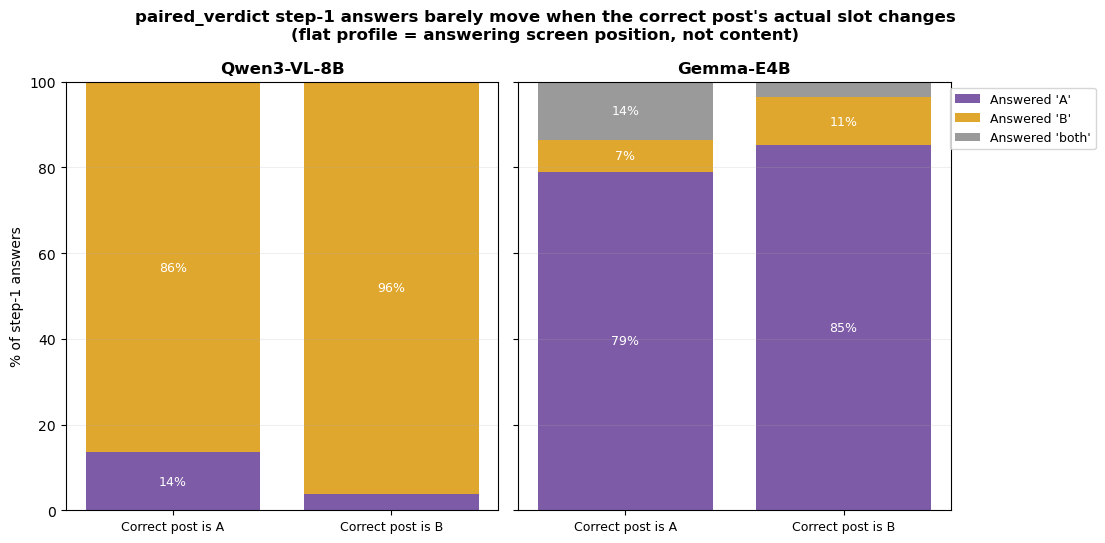

In [6]:
# --- Section 2: paired_verdict positional bias ---
def slot_bias(slug):
    path = REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_diagonal_twostep_paired_verdict.json"
    if not path.exists():
        return None
    data = json.loads(path.read_text())
    out = {}
    for truth_label, truth_val in [("Correct post is A", "correct"), ("Correct post is B", "incorrect")]:
        subset = [r for r in data if r["post_a_variant"] == truth_val]
        n = len(subset)
        c = Counter(r["step1_answer"] for r in subset)
        out[truth_label] = {k: 100 * c.get(k, 0) / n for k in ("a", "b", "both")}
    return out


COLOR_SAID_A = "#7d5ba6"
COLOR_SAID_B = "#e0a72e"
COLOR_SAID_BOTH = "#9a9a9a"

paired_models = [(label, slug) for label, slug in ROSTER
                  if (REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_diagonal_twostep_paired_verdict.json").exists()]

fig, axes = plt.subplots(1, len(paired_models), figsize=(5.5 * len(paired_models), 5.5), sharey=True)
if len(paired_models) == 1:
    axes = [axes]

for ax, (label, slug) in zip(axes, paired_models):
    bias = slot_bias(slug)
    truth_labels = list(bias.keys())
    xs = list(range(len(truth_labels)))
    said_a = [bias[t]["a"] for t in truth_labels]
    said_b = [bias[t]["b"] for t in truth_labels]
    said_both = [bias[t]["both"] for t in truth_labels]

    ax.bar(xs, said_a, label="Answered 'A'", color=COLOR_SAID_A)
    ax.bar(xs, said_b, bottom=said_a, label="Answered 'B'", color=COLOR_SAID_B)
    bottom2 = [a + b for a, b in zip(said_a, said_b)]
    ax.bar(xs, said_both, bottom=bottom2, label="Answered 'both'", color=COLOR_SAID_BOTH)

    for x, (a, b, both) in enumerate(zip(said_a, said_b, said_both)):
        if a > 5:
            ax.text(x, a / 2, f"{a:.0f}%", ha="center", va="center", fontsize=9, color="white")
        if b > 5:
            ax.text(x, a + b / 2, f"{b:.0f}%", ha="center", va="center", fontsize=9, color="white")
        if both > 5:
            ax.text(x, a + b + both / 2, f"{both:.0f}%", ha="center", va="center", fontsize=9, color="white")

    ax.set_xticks(xs)
    ax.set_xticklabels(truth_labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(alpha=0.2, axis="y")

axes[0].set_ylabel("% of step-1 answers")
axes[-1].legend(fontsize=9, loc="upper right", bbox_to_anchor=(1.35, 1))
fig.suptitle("paired_verdict step-1 answers barely move when the correct post's actual slot changes\n(flat profile = answering screen position, not content)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Gemma-E4B answers "A" 79.0% → 85.2% (barely moves, and if anything goes the wrong direction) as the correct post shifts from A to B; Qwen answers "B" 86.2% → 96.2%, same pattern.